# Forecating Global Oil Prices: Bayesian Structural Time Series Model

## Setting up

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss

import collections
import tensorflow.compat.v2 as tf
import tf_keras
import tensorflow_probability as tfp

from tensorflow_probability import distributions as tfd
from tensorflow_probability import sts

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Time series/final_df.csv', index_col=0)

In [ ]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('MS')

### Plotting functions

In [ ]:
def plot_forecast(x, y,
                  forecast_mean, forecast_scale, forecast_samples,
                  title, x_locator=None, x_formatter=None):
  """Plot a forecast distribution against the 'true' time series."""
  colors = sns.color_palette()
  c1, c2 = colors[0], colors[1]
  fig = plt.figure(figsize=(12, 6))
  ax = fig.add_subplot(1, 1, 1)

  num_steps = len(y)
  num_steps_forecast = forecast_mean.shape[-1]
  num_steps_train = num_steps - num_steps_forecast


  ax.plot(x, y, lw=2, color=c1, label='ground truth')


  #forecast_steps = np.arange(
      #x[num_steps_train],
      #x[num_steps_train]+num_steps_forecast,
      #dtype=x.dtype)

  # FIX: Use pd.date_range to generate forecast steps instead of np.arange with direct Timestamp arithmetic.
  # The original line caused a TypeError because direct addition of an integer to a Timestamp is deprecated.
  # x[num_steps_train] is the start date of the forecast period (first date of the test set).
  # num_steps_forecast is the number of periods to forecast.
  # x.freq provides the frequency (e.g., 'MS' for Month Start) from the original time series index.
  forecast_steps = pd.date_range(start=x[num_steps_train], periods=num_steps_forecast, freq=x.freq)

  ax.plot(forecast_steps, forecast_samples.T, lw=1, color=c2, alpha=0.1)

  ax.plot(forecast_steps, forecast_mean, lw=2, ls='--', color=c2,
           label='forecast')
  ax.fill_between(forecast_steps,
                   forecast_mean-2*forecast_scale,
                   forecast_mean+2*forecast_scale, color=c2, alpha=0.2)

  ymin, ymax = min(np.min(forecast_samples), np.min(y)), max(np.max(forecast_samples), np.max(y))
  yrange = ymax-ymin
  ax.set_ylim([ymin - yrange*0.1, ymax + yrange*0.1])
  ax.set_title("{}".format(title))
  ax.legend()

  if x_locator is not None:
    ax.xaxis.set_major_locator(x_locator)
    ax.xaxis.set_major_formatter(x_formatter)
    fig.autofmt_xdate()

  return fig, ax

In [ ]:
def plot_components(dates,
                    component_means_dict,
                    component_stddevs_dict,
                    x_locator=None,
                    x_formatter=None):
  """Plot the contributions of posterior components in a single figure."""
  colors = sns.color_palette()
  c1, c2 = colors[0], colors[1]

  axes_dict = collections.OrderedDict()
  num_components = len(component_means_dict)
  fig = plt.figure(figsize=(12, 2.5 * num_components))
  for i, component_name in enumerate(component_means_dict.keys()):
    component_mean = component_means_dict[component_name]
    component_stddev = component_stddevs_dict[component_name]

    ax = fig.add_subplot(num_components,1,1+i)
    ax.plot(dates, component_mean, lw=2)
    ax.fill_between(dates,
                     component_mean-2*component_stddev,
                     component_mean+2*component_stddev,
                     color=c2, alpha=0.5)
    ax.set_title(component_name)
    if x_locator is not None:
      ax.xaxis.set_major_locator(x_locator)
      ax.xaxis.set_major_formatter(x_formatter)
    axes_dict[component_name] = ax
  fig.autofmt_xdate()
  fig.tight_layout()
  return fig, axes_dict

## Model: supply & demand proxy

### Fit model

In [ ]:
brent = df['Brent_price']
brent_train = brent.iloc[:-24]
brent_test = brent.iloc[-24:]

supply = df['world_crude_supply']
demand = df['global_demand_proxy']

In [ ]:
def build_model(observed_time_series):
  trend = sts.SemiLocalLinearTrend(observed_time_series=observed_time_series)

  seasonal = tfp.sts.Seasonal(
      num_seasons=12,
      observed_time_series=observed_time_series)

  supply_effect = sts.LinearRegression(
      design_matrix=tf.reshape(supply - np.mean(supply), (-1, 1)),
      name='supply_effect'
  )

  demand_effect = sts.LinearRegression(
      design_matrix=tf.reshape(demand - np.mean(demand), (-1, 1)),
      name='demand_effect'
  )

  model = sts.Sum([
      trend,
      seasonal,
      supply_effect,
      demand_effect
      ], observed_time_series=observed_time_series)
  return model

In [ ]:
brent_model = build_model(brent_train)

In [ ]:
# Build the variational surrogate posteriors `qs`.
variational_posteriors = tfp.sts.build_factored_surrogate_posterior(
    model=brent_model)

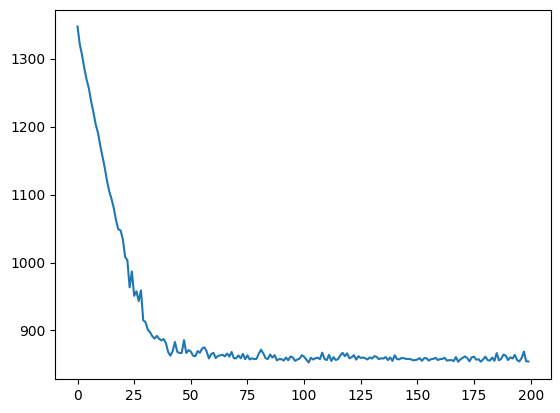

In [ ]:
num_variational_steps = 200
num_variational_steps = int(num_variational_steps)

# Build and optimize the variational loss function.
elbo_loss_curve = tfp.vi.fit_surrogate_posterior(
    target_log_prob_fn=brent_model.joint_distribution(
        observed_time_series=brent_train).log_prob,
    surrogate_posterior=variational_posteriors,
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.1),
    num_steps=num_variational_steps,
    jit_compile=True)

plt.plot(elbo_loss_curve)
plt.show()

# Draw samples from the variational posterior.
q_samples_brent_ = variational_posteriors.sample(50)

In [ ]:
print("Inferred parameters:")
for param in brent_model.parameters:
  print("{}: {} +- {}".format(param.name,
                              np.mean(q_samples_brent_[param.name], axis=0),
                              np.std(q_samples_brent_[param.name], axis=0)))

Inferred parameters:
observation_noise_scale: 0.9030059034160527 +- 0.5005269574956329
SemiLocalLinearTrend/_level_scale: 0.41930626018911427 +- 0.6618251278320141
SemiLocalLinearTrend/_slope_mean: -0.026761285921250145 +- 0.5279515633986388
SemiLocalLinearTrend/_slope_scale: 5.322208149406159 +- 0.2119678221867728
SemiLocalLinearTrend/_autoregressive_coef: 0.34834689916039635 +- 0.04071605020933619
Seasonal/_drift_scale: 0.10118939515136482 +- 0.06712360302939391
supply_effect/_weights: [-0.62854202] +- [0.32998285]
demand_effect/_weights: [0.05606779] +- [0.02138539]


### Forecast

In [ ]:
brent_forecast_dist = tfp.sts.forecast(
    brent_model,
    observed_time_series=brent_train,
    parameter_samples=q_samples_brent_,
    num_steps_forecast=24)

In [ ]:
num_samples=10

brent_forecast_mean, brent_forecast_scale, brent_forecast_samples = (
    brent_forecast_dist.mean().numpy()[..., 0],
    brent_forecast_dist.stddev().numpy()[..., 0],
    brent_forecast_dist.sample(num_samples).numpy()[..., 0])

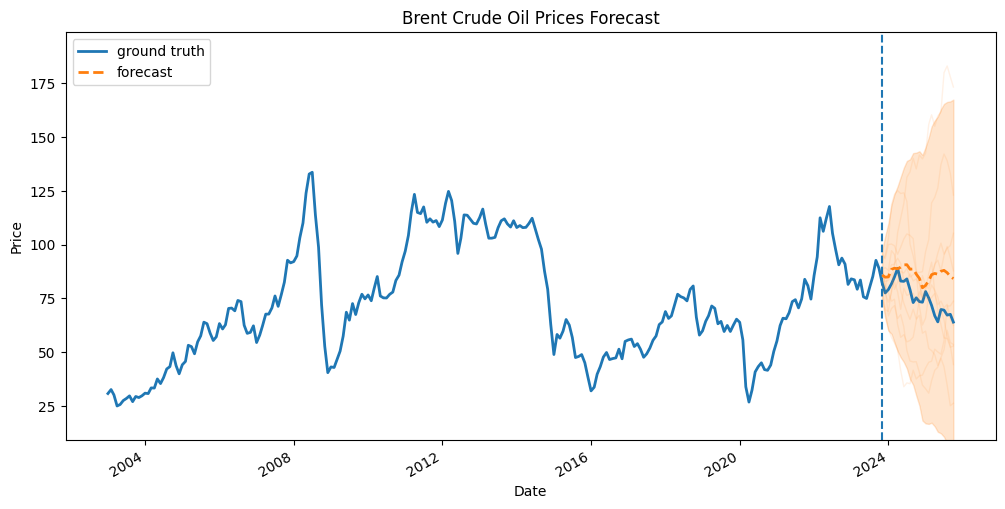

In [ ]:
fig, ax = plot_forecast(
    pd.to_datetime(brent.index), brent.values,
    brent_forecast_mean, brent_forecast_scale, brent_forecast_samples,
    title="Brent Crude Oil Prices Forecast")
ax.axvline(brent.index[-24], linestyle="--")
ax.legend(loc="upper left")
ax.set_ylabel("Price")
ax.set_xlabel("Date")
fig.autofmt_xdate()

In [ ]:
# Build a dict mapping components to distributions over
# their contribution to the observed signal.
component_dists = sts.decompose_by_component(
    brent_model,
    observed_time_series=brent,
    parameter_samples=q_samples_brent_)

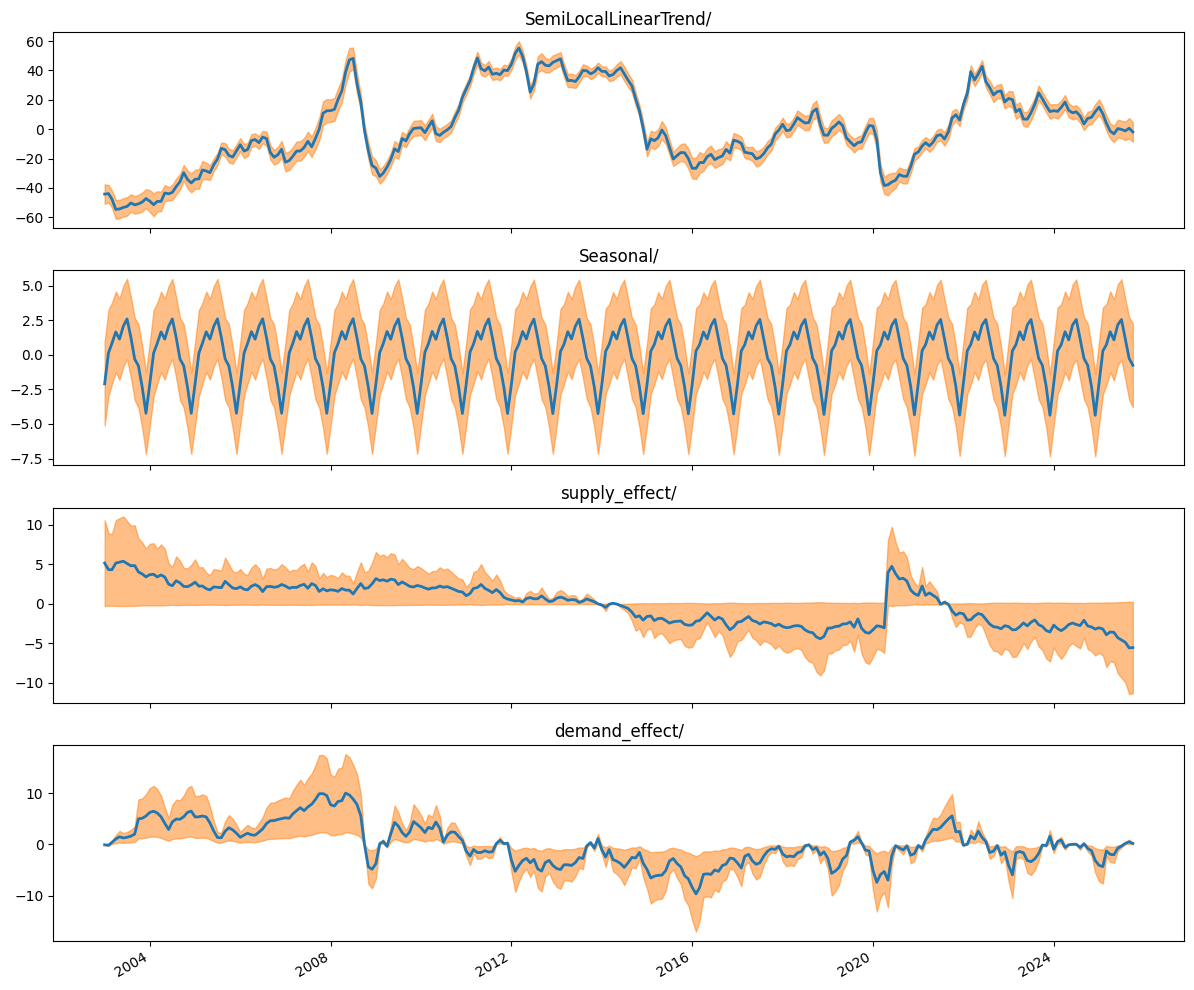

In [ ]:
brent_component_means_, brent_component_stddevs_ = (
    {k.name: c.mean() for k, c in component_dists.items()},
    {k.name: c.stddev() for k, c in component_dists.items()})

_ = plot_components(brent.index, brent_component_means_, brent_component_stddevs_)

In [ ]:
y_test = brent_test.values
y_pred = brent_forecast_mean

# MAE
mae = np.mean(np.abs(y_test - y_pred))

# MSE
mse = np.mean((y_test - y_pred)**2)

# MAPE
mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

# sMAPE
smape = np.mean(
    2 * np.abs(y_test - y_pred) /
    (np.abs(y_test) + np.abs(y_pred))
) * 100

# MASE (seasonal naive benchmark, monthly lag=12)
seasonal_lag = 12
y_train = brent_train

naive_forecast = y_train.shift(seasonal_lag)
naive_errors = y_train[seasonal_lag:] - naive_forecast[seasonal_lag:]
mae_naive = np.mean(np.abs(naive_errors))

mase = mae / mae_naive

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("MAPE:", round(mape, 2))
print("sMAPE:", round(smape, 2))
print("MASE:", round(mase, 2))

MAE: 10.96
MSE: 160.04
MAPE: 15.35
sMAPE: 13.86
MASE: 0.54


In [ ]:
pred_df = pd.DataFrame(
    {
        'date': brent_test.index,
        'actual': brent_test.values,
        'bsts_forecast': brent_forecast_mean,
        'bsts_forecast_lower': brent_forecast_mean - 2 * brent_forecast_scale,
        'bsts_forecast_upper': brent_forecast_mean + 2 * brent_forecast_scale
    }
)

pred_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Time series/bsts_forecast.csv")

In [ ]:
pred_df

,date,actual,bsts_forecast,bsts_forecast_lower,bsts_forecast_upper
0,2023-11-01,82.186364,85.855082,74.201490,97.508675
1,2023-12-01,77.540952,84.856282,65.890798,103.821766
2,2024-01-01,79.110000,84.969337,60.077420,109.861253
3,2024-02-01,81.795714,88.517914,58.503375,118.532454
4,2024-03-01,84.961429,89.023185,54.650702,123.395668
5,2024-04-01,88.974545,88.762607,50.497426,127.027788
6,2024-05-01,83.053913,89.493189,47.663447,131.322931
7,2024-06-01,82.917500,90.567305,45.445096,135.689514
8,2024-07-01,84.048696,90.656160,42.472126,138.840194
9,2024-08-01,79.018636,88.549070,37.485456,139.612685


In [ ]:
%%shell
jupyter nbconvert --to html /content/BSTS_Model.ipynb

[NbConvertApp] Converting notebook /content/BSTS_Model.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 798735 bytes to /content/BSTS_Model.html
